In [1]:
import gc

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm
import gc

In [2]:
plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [3]:
refseq_path = "/extdata4/baeklab/Hyeonseo/m6A/anno/GCF_000001405.40_GRCh38.p14_genomic.gtf"
ensembl_path = "/extdata4/baeklab/Hyeonseo/m6A/anno/Homo_sapiens.GRCh38.113.gtf"

In [17]:
columns = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]

refseq = pd.read_csv(refseq_path, sep= "\t", skiprows=5, names = columns, dtype={"chr":str})
ensembl = pd.read_csv(ensembl_path, sep= "\t", skiprows=5, names = columns, dtype={"chr":str})

print(refseq)
print(ensembl)

                  chr      source     feature    start      end score strand  \
0        NC_000001.11  BestRefSeq        gene  11874.0  14409.0     .      +   
1        NC_000001.11  BestRefSeq  transcript  11874.0  14409.0     .      +   
2        NC_000001.11  BestRefSeq        exon  11874.0  12227.0     .      +   
3        NC_000001.11  BestRefSeq        exon  12613.0  12721.0     .      +   
4        NC_000001.11  BestRefSeq        exon  13221.0  14409.0     .      +   
...               ...         ...         ...      ...      ...   ...    ...   
4697661   NC_012920.1      RefSeq        exon  15888.0  15953.0     .      +   
4697662   NC_012920.1      RefSeq        gene  15956.0  16023.0     .      -   
4697663   NC_012920.1      RefSeq  transcript  15956.0  16023.0     .      -   
4697664   NC_012920.1      RefSeq        exon  15956.0  16023.0     .      -   
4697665           ###         NaN         NaN      NaN      NaN   NaN    NaN   

        frame                          

In [18]:

def ncid_to_chr(ncid):
    ncid_int=ncid.split(".")[0][3:]
    if not ncid_int.isnumeric():
        return "chrUnk"
    else:
        ncid_int = int(ncid_int)
    if ncid_int<=22:
        chr=f"chr{ncid_int}"
    elif ncid_int==23:
        chr="chrX"
    elif ncid_int==24:
        chr="chrY"
    else:
        chr="chrUnk"
    return chr

In [19]:
valid_chr = ["chr"+str(x) for x in range(1,24)]+["chrX","chrY"]

In [20]:
refseq["chr"] = refseq["chr"].apply(ncid_to_chr)
refseq_filtered = refseq[refseq["chr"].isin(valid_chr)]
print(refseq_filtered)

          chr      source     feature       start         end score strand  \
0        chr1  BestRefSeq        gene     11874.0     14409.0     .      +   
1        chr1  BestRefSeq  transcript     11874.0     14409.0     .      +   
2        chr1  BestRefSeq        exon     11874.0     12227.0     .      +   
3        chr1  BestRefSeq        exon     12613.0     12721.0     .      +   
4        chr1  BestRefSeq        exon     13221.0     14409.0     .      +   
...       ...         ...         ...         ...         ...   ...    ...   
4291877  chrY  BestRefSeq        gene  57212178.0  57214703.0     .      -   
4291878  chrY  BestRefSeq  transcript  57212178.0  57214703.0     .      -   
4291879  chrY  BestRefSeq        exon  57214350.0  57214703.0     .      -   
4291880  chrY  BestRefSeq        exon  57213856.0  57213964.0     .      -   
4291881  chrY  BestRefSeq        exon  57212178.0  57213357.0     .      -   

        frame                                          attribut

In [21]:
ensembl["chr"] = "chr"+ensembl["chr"]
ensembl_filtered = ensembl[ensembl["chr"].isin(valid_chr)]
print(ensembl_filtered)

           chr          source      feature    start      end score strand  \
0         chr1  ensembl_havana         gene  3069168  3438621     .      +   
1         chr1          havana   transcript  3069168  3434342     .      +   
2         chr1          havana         exon  3069168  3069296     .      +   
3         chr1          havana          CDS  3069260  3069296     .      +   
4         chr1          havana  start_codon  3069260  3069262     .      +   
...        ...             ...          ...      ...      ...   ...    ...   
4102141  chr21   havana_tagene         exon  9678230  9678353     .      +   
4102142  chr21   havana_tagene         exon  9679515  9679891     .      +   
4102143  chr21   havana_tagene   transcript  9662173  9677705     .      +   
4102144  chr21   havana_tagene         exon  9662173  9662338     .      +   
4102145  chr21   havana_tagene         exon  9677372  9677705     .      +   

        frame                                          attribut

In [22]:
ensembl_filtered_transcript = ensembl_filtered[ensembl_filtered["feature"]=="transcript"]
refseq_filtered_transcript = refseq_filtered[refseq_filtered["feature"]=="transcript"]

print(ensembl_filtered)
print(refseq_filtered)

           chr          source      feature    start      end score strand  \
0         chr1  ensembl_havana         gene  3069168  3438621     .      +   
1         chr1          havana   transcript  3069168  3434342     .      +   
2         chr1          havana         exon  3069168  3069296     .      +   
3         chr1          havana          CDS  3069260  3069296     .      +   
4         chr1          havana  start_codon  3069260  3069262     .      +   
...        ...             ...          ...      ...      ...   ...    ...   
4102141  chr21   havana_tagene         exon  9678230  9678353     .      +   
4102142  chr21   havana_tagene         exon  9679515  9679891     .      +   
4102143  chr21   havana_tagene   transcript  9662173  9677705     .      +   
4102144  chr21   havana_tagene         exon  9662173  9662338     .      +   
4102145  chr21   havana_tagene         exon  9677372  9677705     .      +   

        frame                                          attribut

In [23]:
def attribute_to_dict(attribute):
    attribute_dict = {}
    for attr in attribute.split(";")[:-1]:
        key, value = attr.split('"')[:2]
        key = key.strip()
        attribute_dict[key] = value
    return attribute_dict

In [45]:
print(ensembl_filtered["feature"].value_counts())
print(refseq_filtered["feature"].value_counts())

feature
exon               2154968
CDS                 901755
transcript          385622
three_prime_utr     212414
five_prime_utr      175991
start_codon          99283
stop_codon           93296
gene                 78687
Selenocysteine         130
Name: count, dtype: int64
feature
exon           2105813
CDS            1681795
transcript      181324
start_codon     131423
stop_codon      131198
gene             58930
Name: count, dtype: int64


In [48]:
print(refseq_filtered[refseq_filtered["feature"]=="gene"]["attribute"].values[0])

gene_id "DDX11L1"; transcript_id ""; db_xref "GeneID:100287102"; db_xref "HGNC:HGNC:37102"; description "DEAD/H-box helicase 11 like 1 (pseudogene)"; gbkey "Gene"; gene "DDX11L1"; gene_biotype "transcribed_pseudogene"; pseudo "true"; 


In [49]:
print(ensembl_filtered[ensembl_filtered["feature"]=="gene"]["attribute"].values[0])

gene_id "ENSG00000142611"; gene_version "17"; gene_name "PRDM16"; gene_source "ensembl_havana"; gene_biotype "protein_coding";


In [24]:
ensembl_filtered_transcript = ensembl_filtered_transcript.copy().reset_index(drop=True)
ensembl_filtered_transcript["attribute_dict"] = ensembl_filtered_transcript["attribute"].apply(attribute_to_dict)

In [25]:
refseq_filtered_transcript = refseq_filtered_transcript.copy().reset_index(drop=True)
refseq_filtered_transcript["attribute_dict"] = refseq_filtered_transcript["attribute"].apply(attribute_to_dict)

In [26]:
refseq_filtered_transcript["coding"] = refseq_filtered_transcript["attribute_dict"].apply(lambda x: x.get("transcript_id", "XXXX")[1]=="M")

In [27]:
ensembl_filtered_transcript["coding"] = ensembl_filtered_transcript["attribute_dict"].apply(lambda x: x.get("transcript_biotype", "XXXX")=="protein_coding")

In [28]:
refseq_filtered_transcript_coding = refseq_filtered_transcript[refseq_filtered_transcript["coding"]]
ensembl_filtered_transcript_coding = ensembl_filtered_transcript[ensembl_filtered_transcript["coding"]]
refseq_filtered_transcript_noncoding = refseq_filtered_transcript[~refseq_filtered_transcript["coding"]]
ensembl_filtered_transcript_noncoding = ensembl_filtered_transcript[~ensembl_filtered_transcript["coding"]]

In [29]:
refseq_filtered_transcript["gene_id"] = refseq_filtered_transcript["attribute_dict"].apply(lambda x: x.get("gene_id", "NA"))
ensembl_filtered_transcript["gene_id"] = ensembl_filtered_transcript["attribute_dict"].apply(lambda x: x.get("gene_id", "NA"))

In [30]:
def filter_gtf(df):
    df["start"] = df["start"].astype(int)
    df["end"] = df["end"].astype(int)
    df = df[df["start"]<df["end"]]
    df = df[df["start"]>0]
    df = df[df["gene_id"]!="NA"]
    return df

In [31]:
refseq_filtered_transcript = filter_gtf(refseq_filtered_transcript)
ensembl_filtered_transcript = filter_gtf(ensembl_filtered_transcript)


In [34]:
def write_bed(df, path):
    columns = ["chr", "start", "end", "gene_id", "score", "strand"]
    df = df[columns].copy()
    df.to_csv(path, sep="\t", index=False, header=False)
    return None
    

In [35]:
refseq_filtered_transcript_coding = refseq_filtered_transcript[refseq_filtered_transcript["coding"]]
ensembl_filtered_transcript_coding = ensembl_filtered_transcript[ensembl_filtered_transcript["coding"]]
refseq_filtered_transcript_noncoding = refseq_filtered_transcript[~refseq_filtered_transcript["coding"]]
ensembl_filtered_transcript_noncoding = ensembl_filtered_transcript[~ensembl_filtered_transcript["coding"]]


In [36]:
write_bed(refseq_filtered_transcript_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_transcript_coding.bed")
write_bed(ensembl_filtered_transcript_coding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_transcript_coding.bed")
write_bed(refseq_filtered_transcript_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_transcript_noncoding.bed")
write_bed(ensembl_filtered_transcript_noncoding, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_transcript_noncoding.bed")
write_bed(refseq_filtered_transcript, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/refseq_filtered_transcript.bed")
write_bed(ensembl_filtered_transcript, "/extdata4/baeklab/Hyeonseo/m6A/anno/bed/ensembl_filtered_transcript.bed")

In [37]:
cmd1 = "bedtools sort -i {bed} | bedtools merge -i - > {output}"
cmd2 = "bedtools intersect -a {bed1} -b {bed2} | bedtools sort -i - | bedtools merge -i - > {output}"


In [38]:
wdir = "/extdata4/baeklab/Hyeonseo/m6A/anno/bed"
refseq_transcript_bed = os.path.join(wdir, "refseq_filtered_transcript.bed")
ensembl_transcript_bed = os.path.join(wdir, "ensembl_filtered_transcript.bed")
refseq_coding_bed = os.path.join(wdir, "refseq_filtered_transcript_coding.bed")
ensembl_coding_bed = os.path.join(wdir, "ensembl_filtered_transcript_coding.bed")
refseq_noncoding_bed = os.path.join(wdir, "refseq_filtered_transcript_noncoding.bed")
ensembl_noncoding_bed = os.path.join(wdir, "ensembl_filtered_transcript_noncoding.bed")


In [39]:
for bed in [refseq_transcript_bed, ensembl_transcript_bed, refseq_coding_bed, ensembl_coding_bed, refseq_noncoding_bed, ensembl_noncoding_bed]:
    output = bed.replace(".bed", "_merged.bed")
    os.system(cmd1.format(bed=bed, output=output))

In [40]:
pairs = [(refseq_transcript_bed, ensembl_transcript_bed), (refseq_coding_bed, ensembl_coding_bed), (refseq_noncoding_bed, ensembl_noncoding_bed)]
pairs = [(x[0].replace(".bed", "_merged.bed"), x[1].replace(".bed", "_merged.bed")) for x in pairs]
for bed1, bed2 in pairs:
    output = bed1.replace(".bed", "_intersect.bed")
    os.system(cmd2.format(bed1=bed1, bed2=bed2, output=output))

In [41]:
def get_total_coverage(bed):
    bed = pd.read_csv(bed, sep="\t", header=None)
    total_coverage = np.sum(np.abs(bed[2]-bed[1]))
    return total_coverage

In [42]:
refseq_transcript_cov =  get_total_coverage(refseq_transcript_bed.replace(".bed", "_merged.bed"))
ensembl_transcript_cov = get_total_coverage(ensembl_transcript_bed.replace(".bed", "_merged.bed"))
refseq_coding_cov = get_total_coverage(refseq_coding_bed.replace(".bed", "_merged.bed"))
ensembl_coding_cov = get_total_coverage(ensembl_coding_bed.replace(".bed", "_merged.bed"))
refseq_noncoding_cov = get_total_coverage(refseq_noncoding_bed.replace(".bed", "_merged.bed"))
ensembl_noncoding_cov = get_total_coverage(ensembl_noncoding_bed.replace(".bed", "_merged.bed"))
intersect_transcript_cov = get_total_coverage(refseq_transcript_bed.replace(".bed", "_merged_intersect.bed"))
intersect_coding_cov = get_total_coverage(refseq_coding_bed.replace(".bed", "_merged_intersect.bed"))
intersect_noncoding_cov = get_total_coverage(refseq_noncoding_bed.replace(".bed", "_merged_intersect.bed"))

print(refseq_transcript_cov, ensembl_transcript_cov, intersect_transcript_cov)
print(refseq_coding_cov, ensembl_coding_cov, intersect_coding_cov)
print(refseq_noncoding_cov, ensembl_noncoding_cov, intersect_noncoding_cov)

1650843721 2061403253 1589371069
1252221142 1262581716 1208747317
768019049 1651842415 648856797


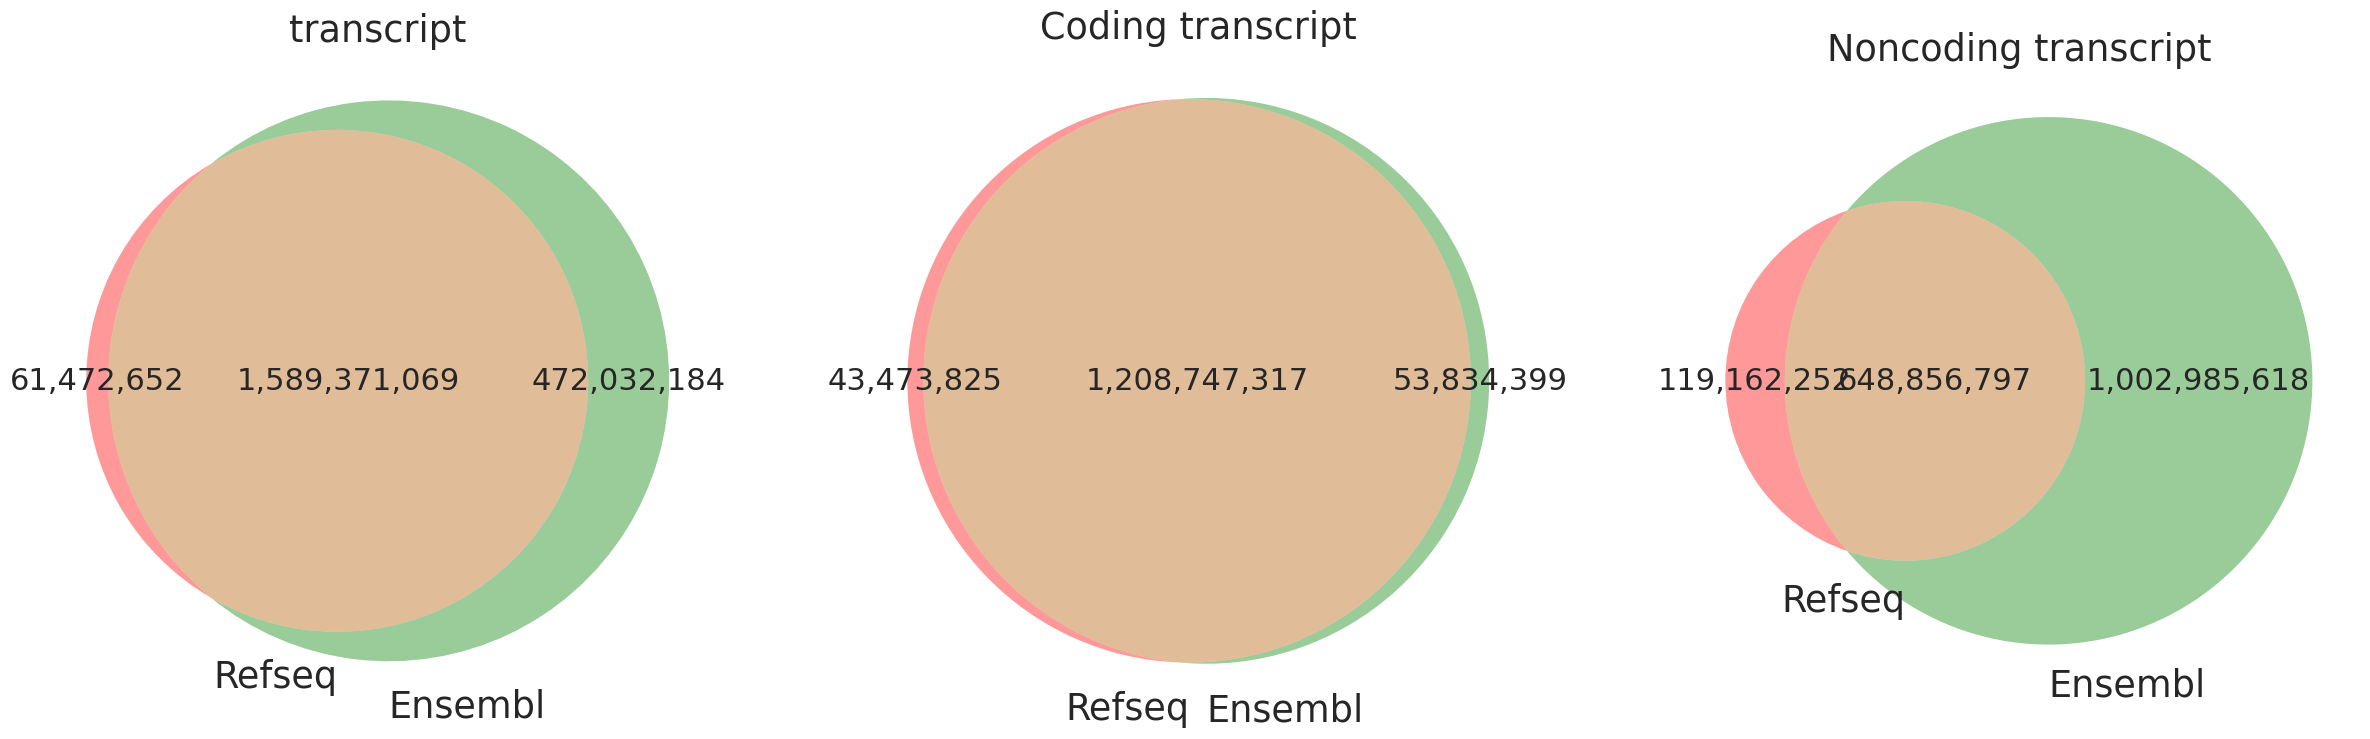

In [44]:
from matplotlib_venn import venn2

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
## Use comma for large numbers
venn2(subsets=(refseq_transcript_cov-intersect_transcript_cov, ensembl_transcript_cov-intersect_transcript_cov, intersect_transcript_cov), set_labels=("Refseq", "Ensembl"), ax=axes[0], subset_label_formatter=lambda x: f"{x:,}")
venn2(subsets=(refseq_coding_cov-intersect_coding_cov, ensembl_coding_cov-intersect_coding_cov, intersect_coding_cov), set_labels=("Refseq", "Ensembl"), ax=axes[1], subset_label_formatter=lambda x: f"{x:,}")
venn2(subsets=(refseq_noncoding_cov-intersect_noncoding_cov, ensembl_noncoding_cov-intersect_noncoding_cov, intersect_noncoding_cov), set_labels=("Refseq", "Ensembl"), ax=axes[2], subset_label_formatter=lambda x: f"{x:,}")
axes[0].set_title("transcript")
axes[1].set_title("Coding transcript")
axes[2].set_title("Noncoding transcript")
plt.show()

